In [ ]:
# Heart disease prediction using Logistic Regression and Decision Tree

In [ ]:
#==========================
# Logistic Regression
#==========================

In [ ]:
#==================
# Import Libraries
#==================

import numpy as np
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

In [ ]:
#============================================
# 1. Load Dataset and handle missing values
#============================================

#================
# 1. Load Dataset
#================

df=pd.read_csv('heart.csv')
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
#========================
# 2. check missing values
#========================

df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
#=================================================================
# 2. Perform Exploratory Data Analysis (EDA) to understand trends
#=================================================================

df.head()
df.shape
df.info()
df.describe()
df['target'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


,count
target,
1,526
0,499


In [ ]:


#========================================================
# 3. Train a classification model (Logistic Regression)
#========================================================

# ===========================
# 3. SPLIT FEATURES & TARGET
# ===========================
X = df.drop(["target","trestbps","fbs","restecg"], axis=1)
y = df["target"]

# ===================
# 4. TRAIN-TEST SPLIT
# ===================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ===============================
# 5. FEATURE SCALING (IMPORTANT)
# ===============================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ===================================
# 6. TRAIN LOGISTIC REGRESSION MODEL
# ====================================
model = LogisticRegression(max_iter=1000,class_weight="balanced")
model.fit(X_train, y_train)

# =================
# 7. PREDICTIONS
# =================
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


Accuracy: 0.8292682926829268

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.75      0.81       100
           1       0.79      0.90      0.84       105

    accuracy                           0.83       205
   macro avg       0.84      0.83      0.83       205
weighted avg       0.84      0.83      0.83       205



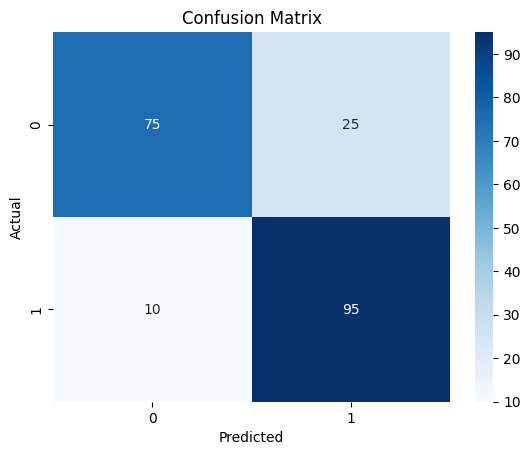

ROC-AUC Score: 0.9279047619047618


In [ ]:
#======================================================================
# 4. Evaluate using metrics: accuracy, ROC curve, and confusion matrix
#======================================================================

# =============
# 8. EVALUATION
# =============
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ======================
# 9. CONFUSION MATRIX
# ======================
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ===============
# 10. ROC CURVE
# ===============
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)



In [ ]:
#==================================================================
# 5. Prediction on unseen data (0 has disease , 1 has no disease)
#==================================================================



# important point == normal heart disease has output values 0 is no disease and 1 has disease but in this dataset its opposite
# 0 has disease and 1 has no disease beacuse when we give higher range values its output is 0 and when we give normal values its output has 1..
# we have option to reverse the labels .... but we use it same
# df['target'] = 1 - df['target']


#===================
#  heart disease (0)
#===================

new_data = pd.DataFrame({
    'cp': [0], # chestpain
    'age':[58],
    'sex':[1],  #1=male,0=female
    'thalach': [140], # heat rate ..... low heart rate increase risk of disease
    'exang': [0], # 1= during exersie anginal pain , 0 =no
    'oldpeak': [4.4], # 0-1 = normal ,1-2=modrate risk ,2-3.5=high risk,>3.5 sever
    'slope': [0], # 0=downslopping(high risk) ,1=flat(med risk) ,2=upslopping(normal)
    'ca': [3], # block vessels
    'thal': [1], # test result of blood flow to heart 1=normal , 2= fixed defect ,3= reversible defect (flow kam hota blood k)
    'chol':[318]
})




#======================
# no  heart disease (1)
#======================

# new_data = pd.DataFrame({
#     'cp': [1], # chestpain
#     'age':[34],
#     'sex':[0],
#     'thalach': [192], # heat rate ..... low heart rate increase risk of disease
#     'exang': [0], # 1= during exersie anginal pain , 0 =no
#     'oldpeak': [0.7], # 0-1 = normal ,1-2=modrate risk ,2-3.5=high risk,>3.5 sever
#     'slope': [2], # 0=downslopping(high risk) ,1=flat(med risk) ,2=upslopping(normal)
#     'ca': [0], # block vessels
#     'thal': [2] , # test result of blood flow to heart 1=normal , 2= fixed defect ,3= reversible defect (flow kam hota blood k)
#     'chol':[210]

# })



#=================
# unseen data
#=================

# new_data = pd.DataFrame({
#     'cp': [0], # chestpain
#     'age':[62],
#     'sex':[0],
#     'thalach': [105], # heat rate ..... low heart rate increase risk of disease
#     'exang': [1], # 1= during exersie anginal pain , 0 =no
#     'oldpeak': [3.5], # 0-1 = normal ,1-2=modrate risk ,2-3.5=high risk,>3.5 sever
#     'slope': [2], # 0=downslopping(high risk) ,1=flat(med risk) ,2=upslopping(normal)
#     'ca': [3], # block vessels
#     'thal': [2] , # test result of blood flow to heart 1=normal , 2= fixed defect ,3= reversible defect (flow kam hota blood k)
#     'chol':[320]
# })


# Ensure correct order
new_data = new_data[X.columns]

# Scale
new_data_scaled = scaler.transform(new_data)

# Predict
prediction = model.predict(new_data_scaled)
probability = model.predict_proba(new_data_scaled)[:, 1]

print("Prediction:", prediction[0])
print("Probability:", probability[0])



Prediction: 0
Probability: 0.007907224991917637


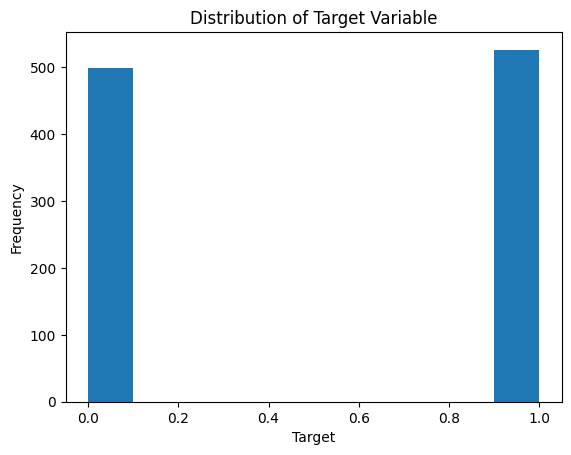

In [ ]:
# ========================
# 11. TARGET DISTRIBUTION
# ========================


plt.hist(df['target'])
plt.title('Distribution of Target Variable')
plt.xlabel('Target')
plt.ylabel('Frequency')
plt.show()

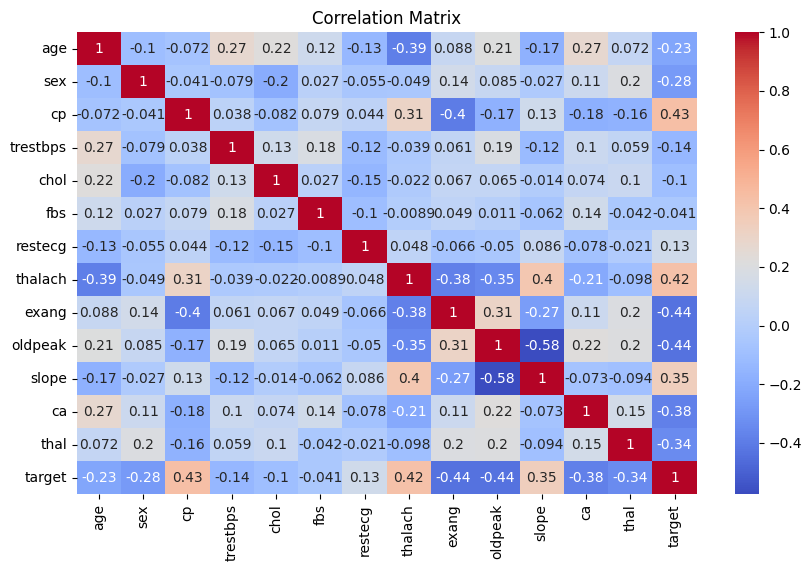

In [ ]:
# ===========================
# 12. CORRELATION OF FEATUERS
# ===========================

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

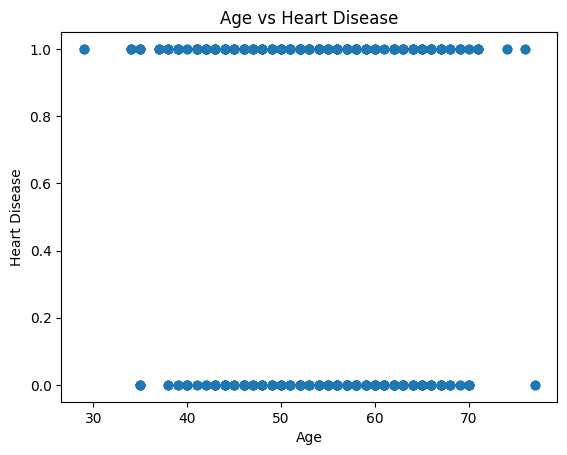

In [ ]:
plt.scatter(df['age'], df['target'])
plt.xlabel('Age')
plt.ylabel('Heart Disease')
plt.title('Age vs Heart Disease')
plt.show()

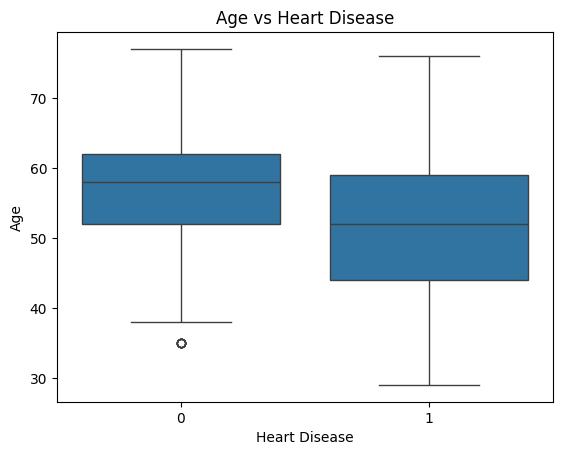

In [ ]:
import seaborn as sns

sns.boxplot(x='target', y='age', data=df)
plt.xlabel('Heart Disease')
plt.ylabel('Age')
plt.title('Age vs Heart Disease')
plt.show()

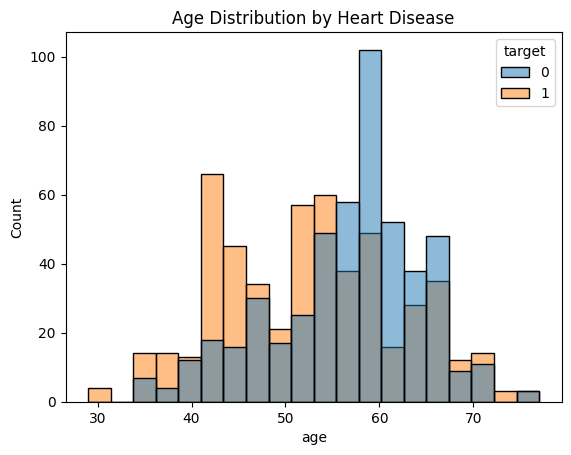

In [ ]:
sns.histplot(data=df, x='age', hue='target', bins=20)
plt.title('Age Distribution by Heart Disease')
plt.show()

In [ ]:
#=================================================================================================
# logistic regression will not work on non linaear patterns that why it missclassify fp and fn
# use tree based model which can work on non linear patterns.
#==================================================================================================

In [ ]:
#=====================
# Train Decision Tree
#=====================

In [16]:
#==================
# Import Libraries
#==================

import numpy as np
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier ,plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

In [17]:
#===========================================
# 1. Load Dataset and handle missing values
#===========================================

#================
# 1. Load Dataset
#================

df=pd.read_csv('heart.csv')
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [18]:
#========================
# 2. check missing values
#========================

df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [19]:
#============================================================
# 3. Train a classification model (Decision Tree Classifier)
#============================================================

# =========================================
# 3. SPLIT FEATURES & TARGET
# =========================================
X = df.drop(["target","chol","trestbps","fbs","restecg"], axis=1)
y = df["target"]

# =========================================
# 4. TRAIN-TEST SPLIT
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



# =========================================
# 6. TRAIN DECISION TREE CLASSIFIER MODEL
# =========================================
model = DecisionTreeClassifier(criterion='entropy')
model.fit(X_train, y_train)

# =========================================
# 7. PREDICTIONS
# =========================================
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]




Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



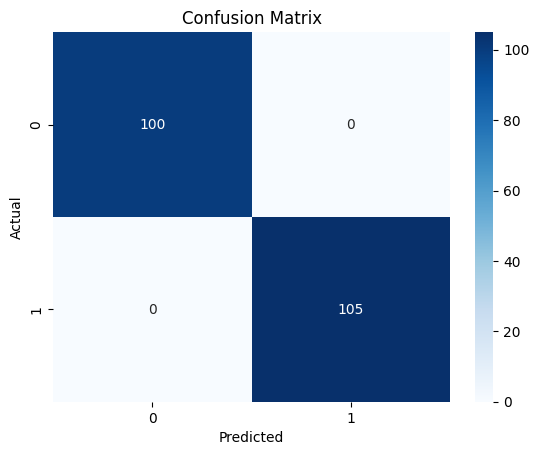

ROC-AUC Score: 1.0


In [20]:
#=======================================================================
# 4. Evaluate using metrics: accuracy, ROC curve, and confusion matrix
#=======================================================================

# =========================================
# 8. EVALUATION
# =========================================
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# =========================================
# 9. CONFUSION MATRIX
# =========================================
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================================
# 10. ROC CURVE
# =========================================
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)



In [21]:
#=================================================================
# 5. Prediction on unseen data (0 has disease , 1 has no disease)
#=================================================================

#===============
# heart disease
#===============

new_data = pd.DataFrame({
    'cp': [0], # chestpain
    'age':[52],
    'sex':[1],  #1=male,0=female
    'thalach': [168], # heat rate ..... low heart rate increase risk of disease
    'exang': [0], # 1= during exersie anginal pain , 0 =no
    'oldpeak': [1], # 0-1 = normal ,1-2=modrate risk ,2-3.5=high risk,>3.5 sever
    'slope': [0], # 0=downslopping(high risk) ,1=flat(med risk) ,2=upslopping(normal)
    'ca': [2], # block vessels
    'thal': [2] # test result of blood flow to heart 1=normal , 2= fixed defect ,3= reversible defect (flow kam hota blood k)
})




#=================
# no heart disease
#=================

# new_data = pd.DataFrame({
#     'cp': [0], # chestpain
#     'age':[34],
#     'sex':[0],
#     'thalach': [192], # heat rate ..... low heart rate increase risk of disease
#     'exang': [0], # 1= during exersie anginal pain , 0 =no
#     'oldpeak': [0.7], # 0-1 = normal ,1-2=modrate risk ,2-3.5=high risk,>3.5 sever
#     'slope': [2], # 0=downslopping(high risk) ,1=flat(med risk) ,2=upslopping(normal)
#     'ca': [0], # block vessels
#     'thal': [2] # test result of blood flow to heart 1=normal , 2= fixed defect ,3= reversible defect (flow kam hota blood k)
# })




# Ensure correct order
new_data = new_data[X.columns]


# Predict
prediction = model.predict(new_data)
probability = model.predict_proba(new_data)[:, 1]

print("Prediction:", prediction[0])
print("Probability:", probability[0])



Prediction: 0
Probability: 0.0


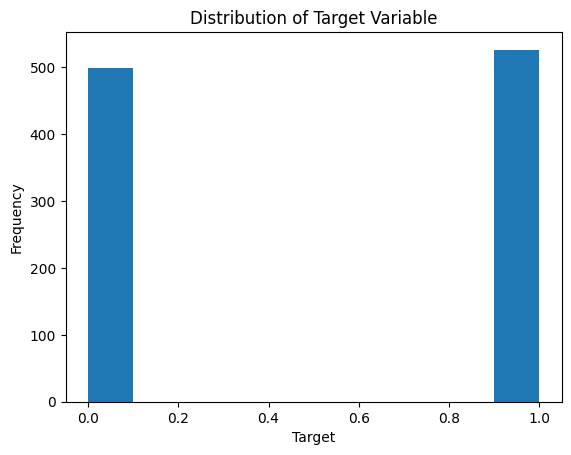

In [22]:
# ========================
# 11. TARGET DISTRIBUTION
# ========================


plt.hist(df['target'])
plt.title('Distribution of Target Variable')
plt.xlabel('Target')
plt.ylabel('Frequency')
plt.show()

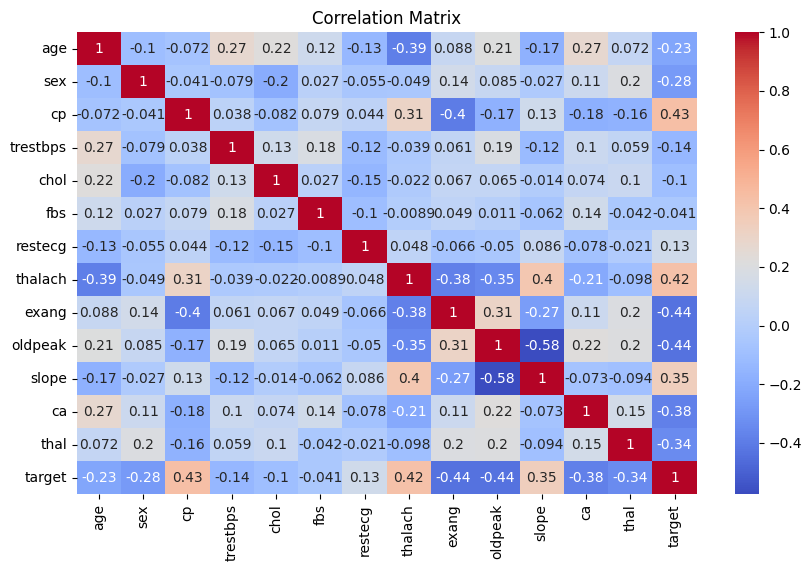

In [23]:
# ===========================
# 12. CORRELATION OF FEATUERS
# ===========================

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()